In [1]:
import numpy as np
import kagglehub
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.feature import hog
from sklearn.preprocessing import StandardScaler



path = kagglehub.dataset_download("shahriar26s/banana-ripeness-classification-dataset")


train_dir = Path("/kaggle/input/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset/train")
val_dir = Path("/kaggle/input/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset/valid")
test_dir = Path("/kaggle/input/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset/test")

def load_split(split_dir):
    image_paths = []
    labels = []
    # Detect class folders (Green, SemiRipe, Ripe, Overripe)
    class_names = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    
    for label_idx, class_name in enumerate(class_names):
        class_folder = split_dir / class_name
        
        # Collect all image files
        for img_path in class_folder.glob("*.jpg"):
            image_paths.append(str(img_path))
            labels.append(label_idx)
    
    return np.array(image_paths), np.array(labels), class_names


# Load each split
x_train, y_train, class_names = load_split(train_dir)
x_val,   y_val,   _           = load_split(val_dir)
x_test,  y_test,  _           = load_split(test_dir)

print("Classes:", class_names)
print("Train images:", len(x_train))
print("Val images:", len(x_val))
print("Test images:", len(x_test))

Classes: ['overripe', 'ripe', 'rotten', 'unripe']
Train images: 11793
Val images: 1123
Test images: 562


In [2]:
import cv2
import numpy as np

IMG_SIZE = (128, 128)  # keep all images consistent

def extract_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    
    features = []
    
    for c in range(3):
        channel = hsv[:, :, c]
        features.append(channel.mean())
        features.append(channel.std())
    
    for c in range(3):
        channel = lab[:, :, c]
        features.append(channel.mean())
        features.append(channel.std())
    
    h, s, v = cv2.split(hsv)
    brown_mask = ((h > 5) & (h < 25) & (s > 40) & (v < 180)).astype(np.uint8)
    
    brown_ratio = brown_mask.mean()
    features.append(brown_ratio)

    for c in range(3):
        hist = cv2.calcHist([hsv], [c], None, [16], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        features.extend(hist)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        transform_sqrt=True,
        feature_vector=True
    )

    features.extend(hog_features)

    return np.array(features, dtype=np.float32)
    


In [3]:
test_vector = extract_features(x_train[0])
print(test_vector)
print("Feature vector length:", len(test_vector))

[68.66144  48.643227 43.133545 ...  0.        0.        0.      ]
Feature vector length: 1825


In [4]:
def build_feature_matrix(image_paths):
    feature_list = []
    for path in tqdm(image_paths, desc="Extracting features"):
        features = extract_features(path)
        feature_list.append(features)
    return np.vstack(feature_list)

# Extract features for each split
x_train = build_feature_matrix(x_train)
x_val   = build_feature_matrix(x_val)
x_test  = build_feature_matrix(x_test)

# Convert labels to numpy arrays (if not already)
y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

print("X_train shape:", x_train.shape)
print("X_val shape:", x_val.shape)
print("X_test shape:", x_test.shape)

Extracting features: 100%|██████████| 562/562 [00:07<00:00, 75.59it/s]

X_train shape: (11793, 1825)
X_val shape: (1123, 1825)
X_test shape: (562, 1825)


In [5]:
x_all = np.vstack([x_train, x_val, x_test])
y_all = np.concatenate([y_train, y_val, y_test])

print("Combined shape:", x_all.shape, y_all.shape)


Combined shape: (13478, 1825) (13478,)


In [6]:
from sklearn.utils import shuffle

x_all, y_all = shuffle(x_all, y_all, random_state=0)


In [7]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    x_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", x_train.shape)
print("Val:",   x_val.shape)
print("Test:",  x_test.shape)


Train: (9434, 1825)
Val: (2022, 1825)
Test: (2022, 1825)


In [8]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

print("Scaled shapes:")
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

Scaled shapes:
(9434, 1825)
(2022, 1825)
(2022, 1825)


In [9]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    tree_method="hist",
    learning_rate=0.05,
    n_estimators=400,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    min_child_weight=3,
    eval_metric="mlogloss"
)

final_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_class=4, num_parallel_tree=None, ...)

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

val_pred = final_model.predict(x_val)
val_acc = accuracy_score(y_val, val_pred)
print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.9614243323442137


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

XGboost:
Accuracy: 96.44%

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       404
           1       0.96      0.97      0.97       602
           2       0.96      0.96      0.96       689
           3       0.98      0.98      0.98       327

    accuracy                           0.96      2022
   macro avg       0.97      0.97      0.97      2022
weighted avg       0.96      0.96      0.96      2022



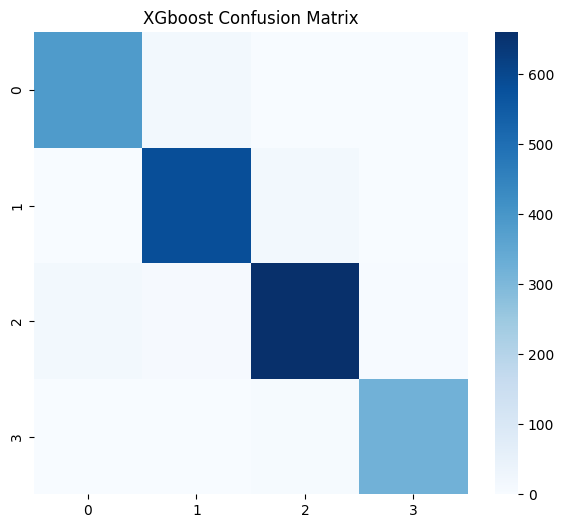

In [12]:
def final_results(model, Xtest, ytest, name):
    preds = model.predict(Xtest)
    print(f"{name}:")
    print(f"Accuracy: {(accuracy_score(ytest, preds) * 100):.2f}%")
    print("\nClassification Report:\n", classification_report(ytest, preds))
    cm = confusion_matrix(ytest, preds)

    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

final_results(final_model,  x_test, y_test, "XGboost")